In [2]:
import pandas as pd
df = pd.read_csv('train.csv')

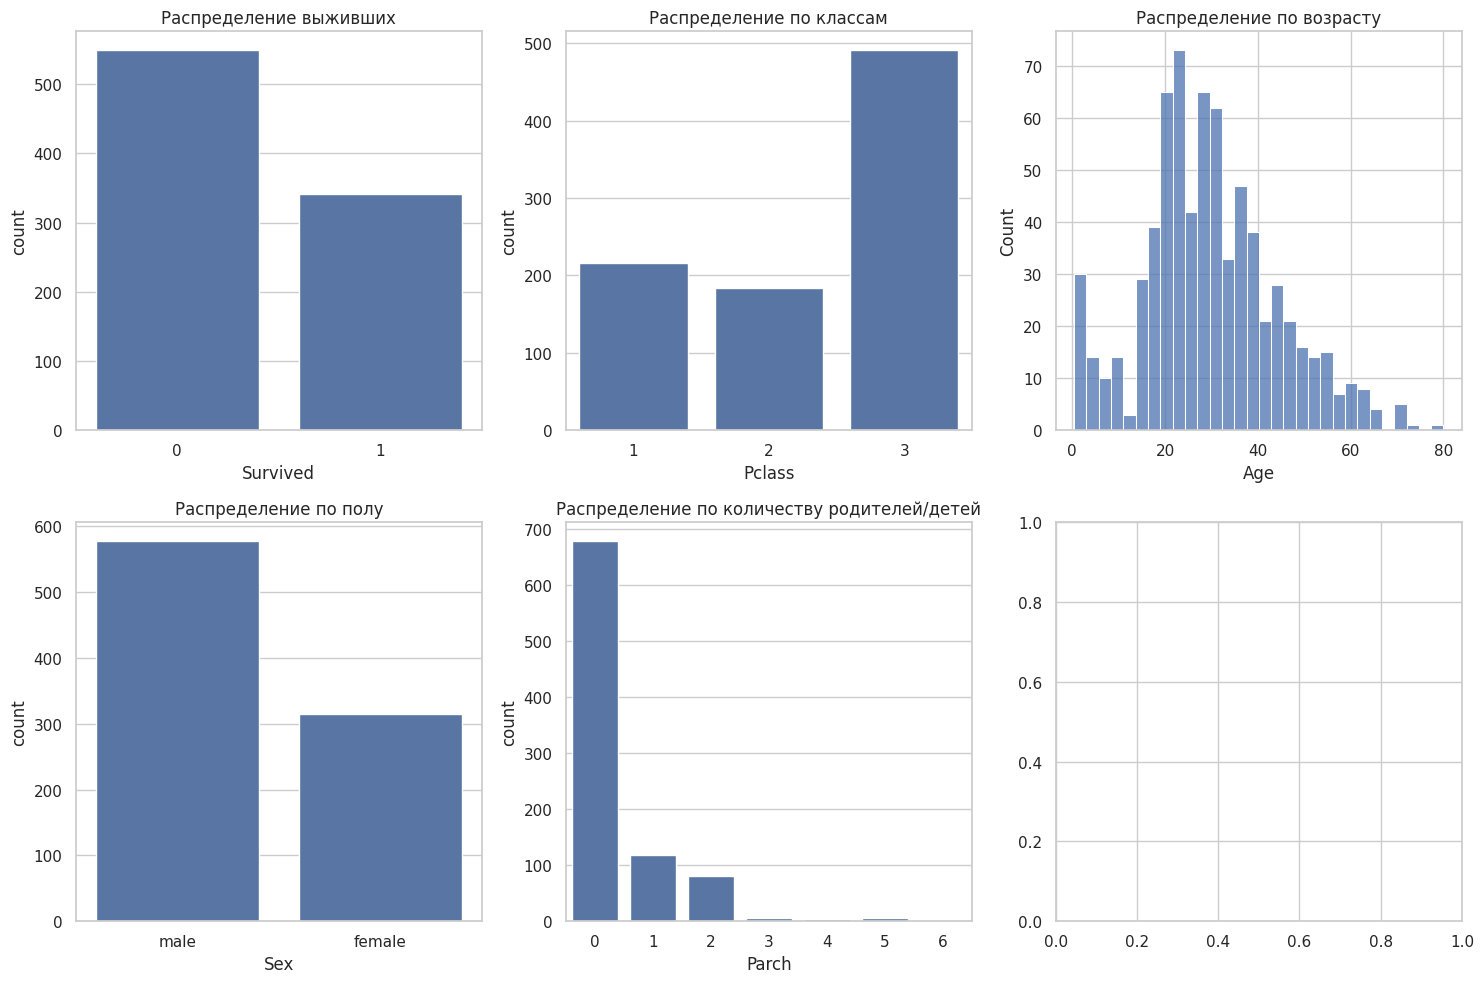

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

fig, axes = plt.subplots(2,3, figsize=(15,10))

sns.countplot (x='Survived', data=df, ax=axes[0,0])
axes[0,0].set_title('Распределение выживших')

sns.countplot(x='Pclass', data=df, ax=axes[0,1])
axes[0,1].set_title('Распределение по классам')

sns.histplot(df['Age'].dropna(),bins=30, ax=axes[0,2])
axes[0,2].set_title('Распределение по возрасту')

sns.countplot(x='Sex', data=df, ax=axes[1,0])
axes[1,0].set_title('Распределение по полу')

sns.countplot(x='Parch', data=df,ax=axes[1,1])
axes[1,1].set_title('Распределение по количеству родителей/детей')

plt.tight_layout()
plt.show()

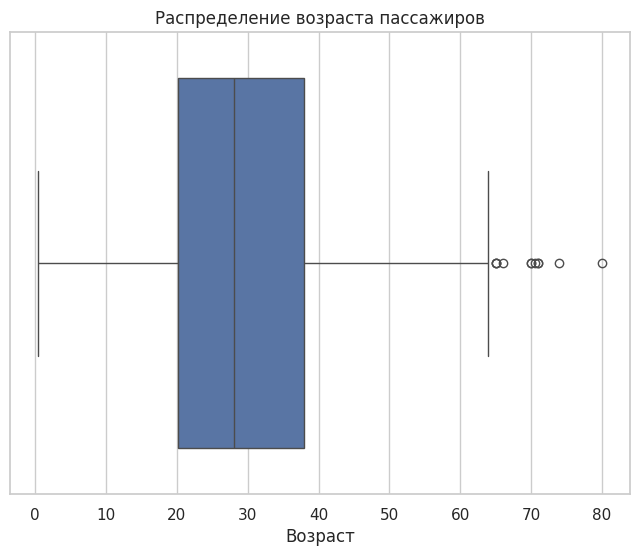

In [6]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['Age'].dropna())
plt.title('Распределение возраста пассажиров')
plt.xlabel('Возраст')
plt.show()

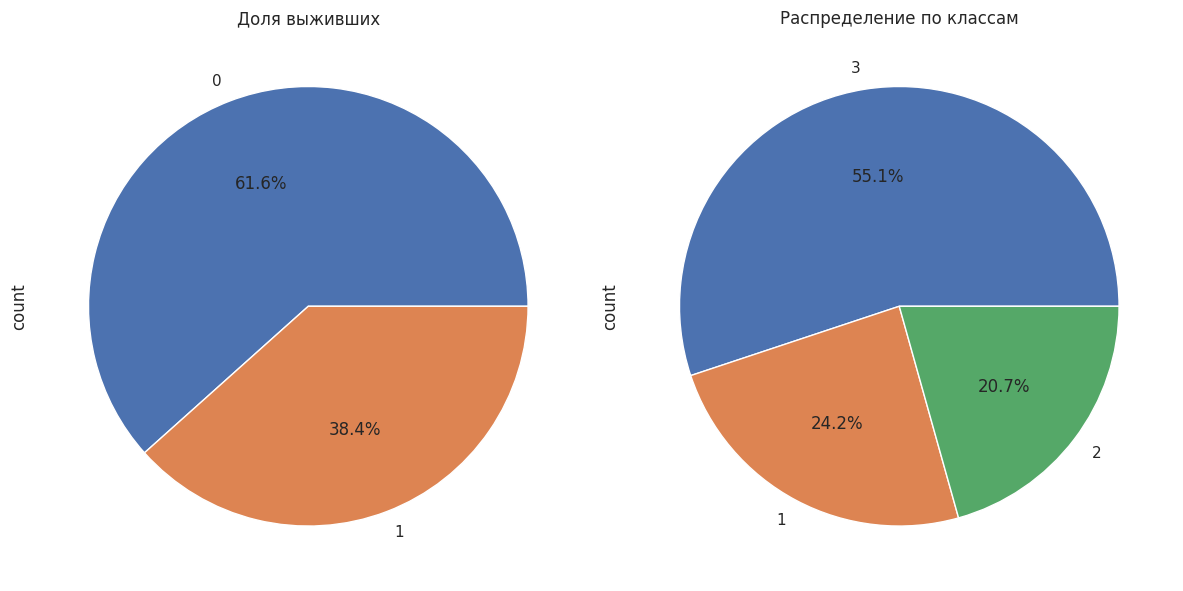

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

df['Survived'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[0])
axes[0].set_title('Доля выживших')

df['Pclass'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1])
axes[1].set_title('Распределение по классам')

plt.tight_layout()
plt.show()

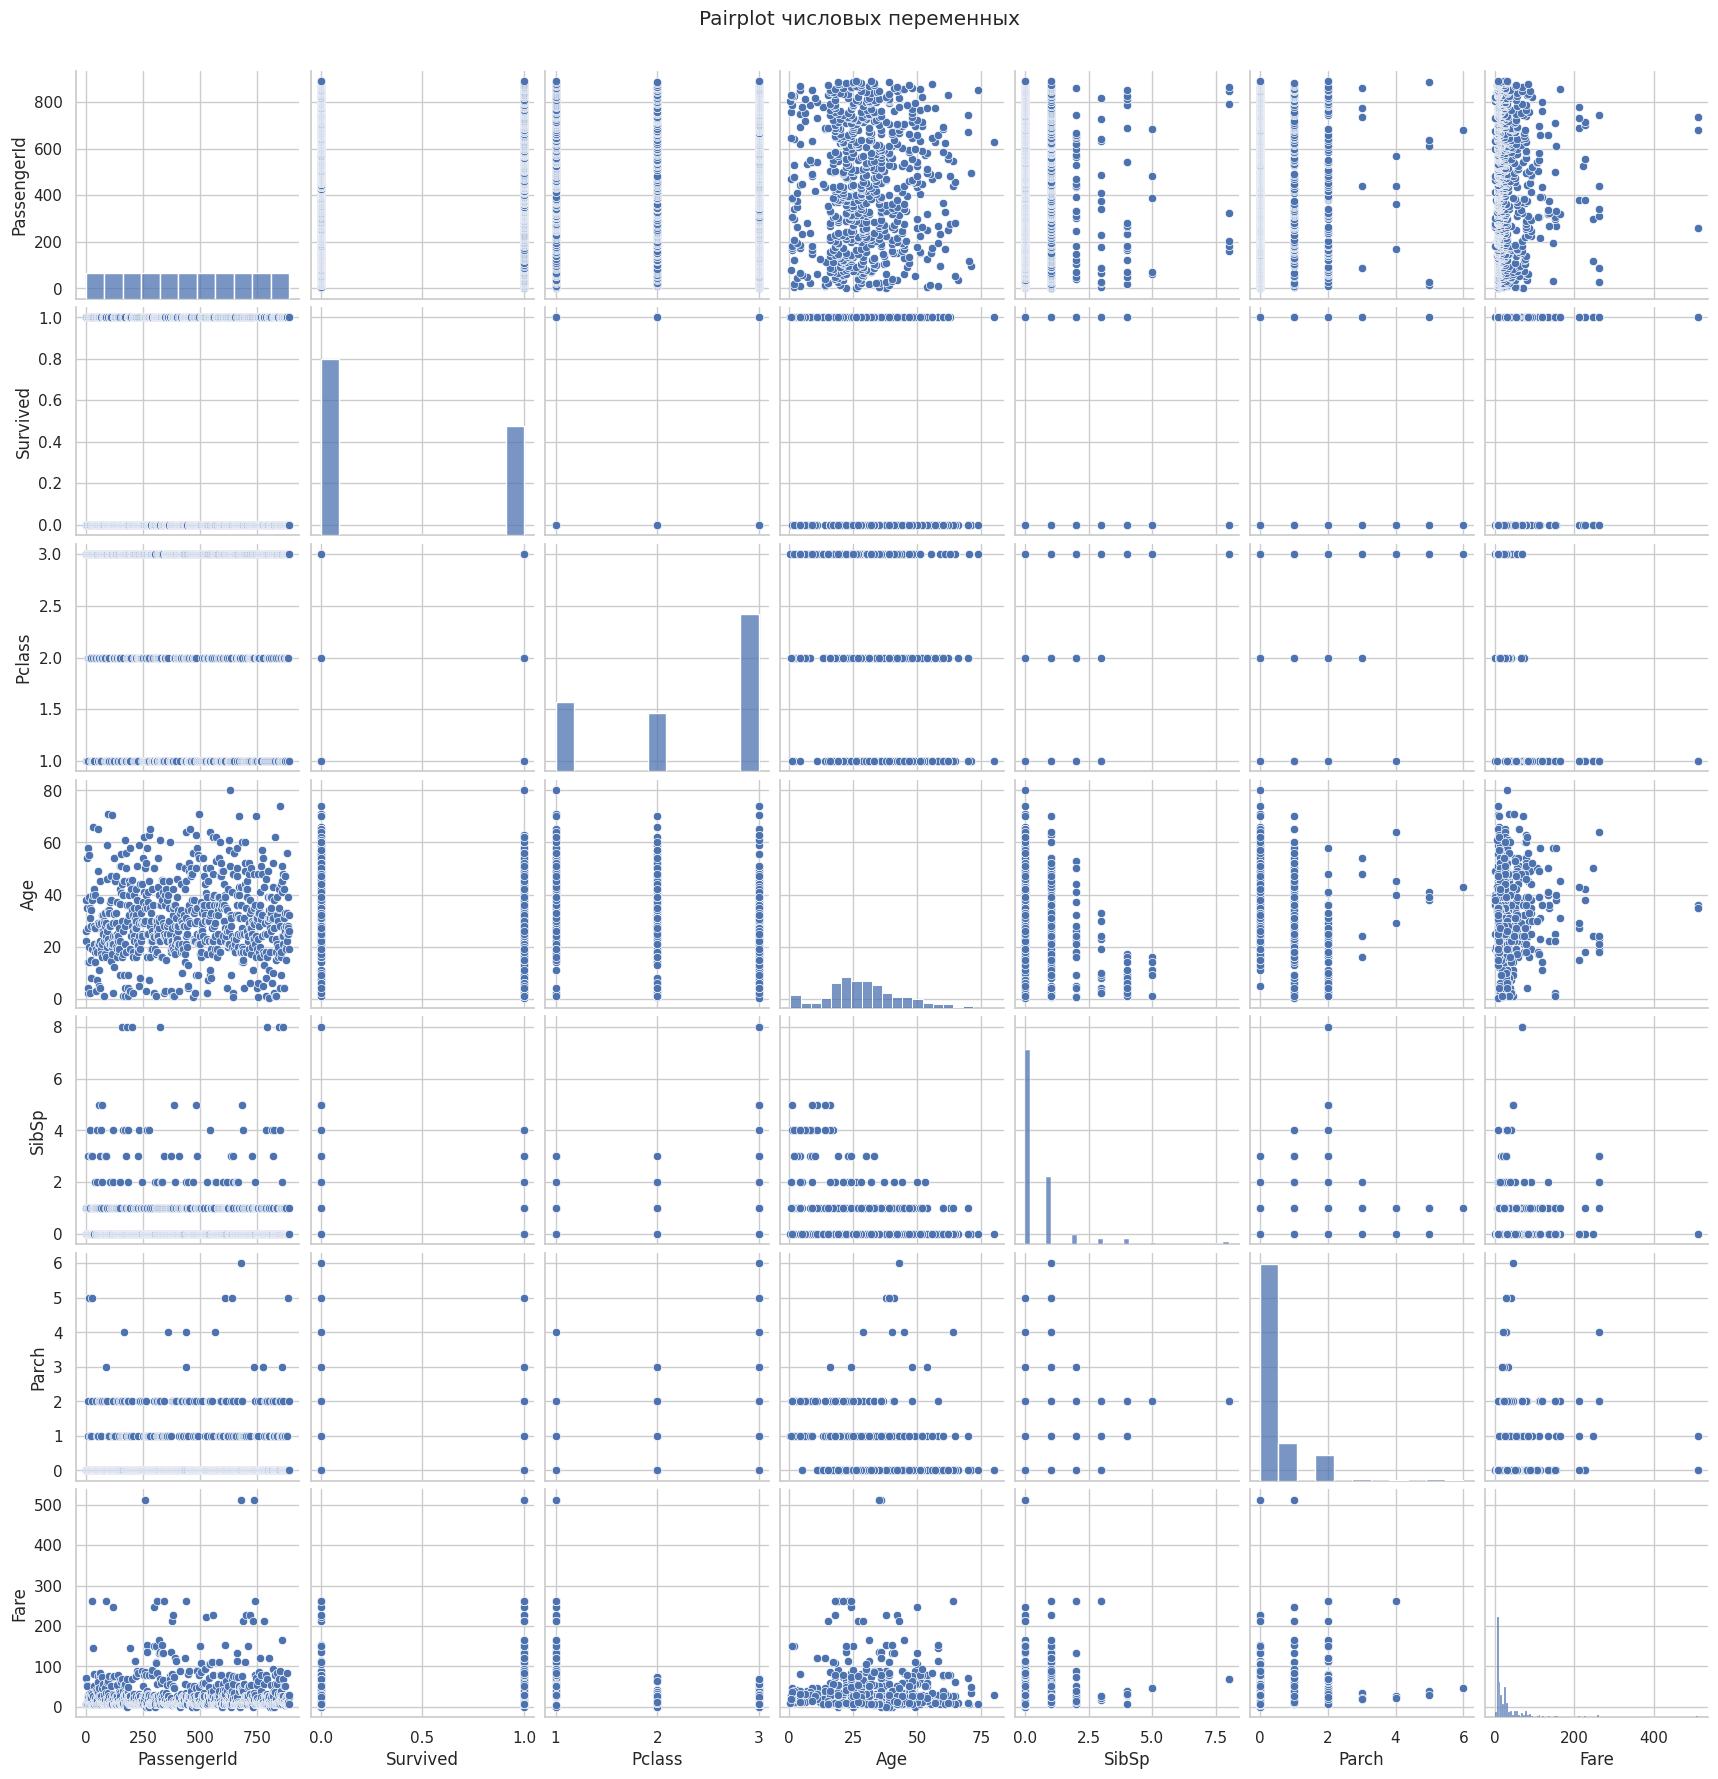

In [10]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns
sns.pairplot(df[numerical_cols])
plt.suptitle('Pairplot числовых переменных', y=1.02)
plt.show()

In [11]:
import plotly.express as px

class_sex_counts = df.groupby(['Pclass', 'Sex']).size().reset_index(name='counts')

fig=px.sunburst(
    class_sex_counts,
    path = ['Pclass', 'Sex'],
    values='counts',
    title='Распределение пассажиров по классам и полу'
)
fig.show()